# 01 - Data Exploration

## Project
Women's Football Analytics System

## Goal

The goal of this notebook is to explore the available StatsBomb Open Data competitions and select an appropriate dataset for further analysis.

The selected competition will be used throughout the project for player performance analysis and prediction of attacking success in the FA Women's Super League.

In [3]:
from statsbombpy import sb
import pandas as pd
import matplotlib.pyplot as plt
from mplsoccer import Pitch

In [4]:
pd.set_option("display.max_columns", None)

## Available competitions

StatsBomb Open Data contains multiple domestic and international football competitions.

The first step is to inspect all available competitions and identify datasets related to women's football.

In [5]:
competitions = sb.competitions()

competitions

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
0,9,281,Germany,1. Bundesliga,male,False,False,2023/2024,2024-09-28T20:46:38.893391,2025-11-15T23:17:41.827093,2025-11-15T23:17:41.827093,2024-09-28T20:46:38.893391
1,9,27,Germany,1. Bundesliga,male,False,False,2015/2016,2024-05-19T11:11:14.192381,NaN,NaN,2024-05-19T11:11:14.192381
2,1267,107,Africa,African Cup of Nations,male,False,True,2023,2026-05-12T21:18:08.827431,2026-05-02T02:07:18.902396,2026-05-02T02:07:18.902396,2026-05-12T21:18:08.827431
3,16,4,Europe,Champions League,male,False,False,2018/2019,2026-05-15T15:54:04.598614,2021-06-13T16:17:31.694,NaN,2026-05-15T15:54:04.598614
4,16,1,Europe,Champions League,male,False,False,2017/2018,2024-02-13T02:35:28.134882,2021-06-13T16:17:31.694,NaN,2024-02-13T02:35:28.134882
...,...,...,...,...,...,...,...,...,...,...,...,...
75,35,75,Europe,UEFA Europa League,male,False,False,1988/1989,2026-04-11T12:48:10.012987,2021-06-13T16:17:31.694,NaN,2026-04-11T12:48:10.012987
76,53,315,Europe,UEFA Women's Euro,female,False,True,2025,2026-04-27T22:02:42.690507,2026-04-27T22:03:28.087062,2026-04-27T22:03:28.087062,2026-04-27T22:02:42.690507
77,53,106,Europe,UEFA Women's Euro,female,False,True,2022,2026-05-05T03:03:04.199896,2026-05-05T03:05:32.480837,2026-05-05T03:05:32.480837,2026-05-05T03:03:04.199896
78,72,107,International,Women's World Cup,female,False,True,2023,2026-05-03T13:51:31.021141,2026-05-03T13:55:52.303219,2026-05-03T13:55:52.303219,2026-05-03T13:51:31.021141


In [6]:
competitions.shape

(80, 12)

In [7]:
competitions.info()

<class 'pandas.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   competition_id             80 non-null     int64
 1   season_id                  80 non-null     int64
 2   country_name               80 non-null     str  
 3   competition_name           80 non-null     str  
 4   competition_gender         80 non-null     str  
 5   competition_youth          80 non-null     bool 
 6   competition_international  80 non-null     bool 
 7   season_name                80 non-null     str  
 8   match_updated              80 non-null     str  
 9   match_updated_360          58 non-null     str  
 10  match_available_360        12 non-null     str  
 11  match_available            80 non-null     str  
dtypes: bool(2), int64(2), str(8)
memory usage: 6.5 KB


In [11]:
competitions.describe(include="all")

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
count,80.000000,80.000000,80,80,80,80,80,80,80,58,12,80
unique,NaN,NaN,13,24,2,2,2,48,80,15,12,80
top,NaN,NaN,Europe,Champions League,male,False,False,2015/2016,2024-09-28T20:46:38.893391,2021-06-13T16:17:31.694,2025-11-15T23:17:41.827093,2024-09-28T20:46:38.893391
freq,NaN,NaN,23,18,67,79,63,6,1,44,1,1
mean,84.587500,99.825000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,250.356995,103.636875,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,2.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,11.000000,26.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,16.000000,44.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,49.000000,108.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
women_competitions = competitions[
    competitions["competition_gender"] == "female"
]

women_competitions

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
25,37,281,England,FA Women's Super League,female,False,False,2023/2024,2026-04-11T13:05:10.794831,NaN,NaN,2026-04-11T13:05:10.794831
26,37,90,England,FA Women's Super League,female,False,False,2020/2021,2026-04-12T16:33:48.145602,2021-06-13T16:17:31.694,NaN,2026-04-12T16:33:48.145602
27,37,42,England,FA Women's Super League,female,False,False,2019/2020,2026-04-12T16:07:56.102610,2021-06-13T16:17:31.694,NaN,2026-04-12T16:07:56.102610
28,37,4,England,FA Women's Super League,female,False,False,2018/2019,2026-03-28T18:13:53.368475,2021-06-13T16:17:31.694,NaN,2026-03-28T18:13:53.368475
38,135,281,Germany,Frauen Bundesliga,female,False,False,2023/2024,2026-04-11T13:05:50.947635,NaN,NaN,2026-04-11T13:05:50.947635
58,182,281,Spain,Liga F,female,False,False,2023/2024,2026-04-11T15:32:55.463202,NaN,NaN,2026-04-11T15:32:55.463202
66,49,107,United States of America,NWSL,female,False,False,2023,2026-04-08T09:41:46.347347,NaN,NaN,2026-04-08T09:41:46.347347
67,49,3,United States of America,NWSL,female,False,False,2018,2024-12-15T12:31:48.035735,2021-06-13T16:17:31.694,NaN,2024-12-15T12:31:48.035735
72,131,281,Italy,Serie A Women,female,False,False,2023/2024,2026-04-11T13:29:49.465639,NaN,NaN,2026-04-11T13:29:49.465639
76,53,315,Europe,UEFA Women's Euro,female,False,True,2025,2026-04-27T22:02:42.690507,2026-04-27T22:03:28.087062,2026-04-27T22:03:28.087062,2026-04-27T22:02:42.690507


In [12]:
women_competitions[
    [
        "country_name",
        "competition_name",
        "season_name"
    ]
]

,country_name,competition_name,season_name
25,England,FA Women's Super League,2023/2024
26,England,FA Women's Super League,2020/2021
27,England,FA Women's Super League,2019/2020
28,England,FA Women's Super League,2018/2019
38,Germany,Frauen Bundesliga,2023/2024
58,Spain,Liga F,2023/2024
66,United States of America,NWSL,2023
67,United States of America,NWSL,2018
72,Italy,Serie A Women,2023/2024
76,Europe,UEFA Women's Euro,2025


## Competition selection

Several women's competitions are available.

For this project, the FA Women's Super League (England, season 2023/2024) was selected because it contains a complete season of event-based data and represents one of the highest-quality women's football competitions.

In [16]:
matches_fawsl = sb.matches(
    competition_id=37,
    season_id=281
)

matches_fawsl

,match_id,match_date,kick_off,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,match_week,competition_id,competition_country_name,competition_name,competition,season_id,season,home_team_id,home_team,home_team_gender,home_team_group,home_team_country_id,home_team_country_name,away_team_id,away_team,away_team_gender,away_team_group,away_team_country_id,away_team_country_name,competition_stage_id,competition_stage,stadium_id,stadium,stadium_country_id,stadium_country_name,referee_id,referee,referee_country_id,referee_country_name,home_managers,away_managers,home_manager_id,home_manager_name,home_manager_nickname,home_manager_dob,home_manager_country_id,home_manager_country_name,away_manager_id,away_manager_name,away_manager_nickname,away_manager_dob,away_manager_country_id,away_manager_country_name,data_version,shot_fidelity_version,xy_fidelity_version
0,3913082,2023-11-05,18:45:00.000,2,2,available,unscheduled,2026-04-11T13:03:17.779673,None,5,37,England,FA Women's Super League,England - FA Women's Super League,281,2023/2024,965,Brighton & Hove Albion WFC,female,None,68,England,1475,Manchester United W,female,None,68,England,1,Regular Season,4494,Broadfield Stadium,68,England,926.0,Elizabeth Simms,68.0,England,Melissa Phillips,Marc Skinner,1002160,Melissa Phillips,None,NaN,68,England,128,Marc Skinner,None,1983-03-23,68,England,1.1.0,2,2
1,3913155,2024-03-23,12:30:00.000,3,1,available,unscheduled,2026-04-11T13:01:12.427016,None,17,37,England,FA Women's Super League,England - FA Women's Super League,281,2023/2024,746,Manchester City WFC,female,None,68,England,1475,Manchester United W,female,None,68,England,1,Regular Season,4715,Etihad Stadium,68,England,937.0,Abigail Byrne,68.0,England,Gareth Taylor,Marc Skinner,5115,Gareth Taylor,None,1973-02-25,249,Wales,128,Marc Skinner,None,1983-03-23,68,England,1.1.0,2,2
2,3913167,2024-04-21,11:00:00.000,2,2,available,unscheduled,2026-04-10T15:02:10.119805,None,19,37,England,FA Women's Super League,England - FA Women's Super League,281,2023/2024,1475,Manchester United W,female,None,68,England,749,Tottenham Hotspur Women,female,None,68,England,1,Regular Season,4979,Leigh Sports Village Stadium,68,England,566.0,Rebecca Welch,68.0,England,Marc Skinner,Robert Vilahamn,128,Marc Skinner,None,1983-03-23,68,England,1000768,Robert Vilahamn,None,1983-01-02,220,Sweden,1.1.0,2,2
3,3913175,2024-04-28,13:00:00.000,1,1,available,unscheduled,2026-04-07T09:17:31.343400,None,20,37,England,FA Women's Super League,England - FA Women's Super League,281,2023/2024,2647,Aston Villa W,female,None,68,England,972,West Ham United LFC,female,None,68,England,1,Regular Season,211,Villa Park,68,England,1711.0,Emily Heaslip,68.0,England,Carla Ward,Rehanne Skinner,3978,Carla Ward,None,1982-12-21,68,England,5389,Rehanne Skinner,None,1979-11-13,68,England,1.1.0,2,2
4,3913107,2023-12-09,12:00:00.000,2,1,available,unscheduled,2026-04-07T09:17:06.305626,None,9,37,England,FA Women's Super League,England - FA Women's Super League,281,2023/2024,746,Manchester City WFC,female,None,68,England,2647,Aston Villa W,female,None,68,England,1,Regular Season,99,Joie Stadium,68,England,937.0,Abigail Byrne,68.0,England,Gareth Taylor,Carla Ward,5115,Gareth Taylor,None,1973-02-25,249,Wales,3978,Carla Ward,None,1982-12-21,68,England,1.1.0,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,3912597,2023-10-01,19:30:00.000,2,1,available,unscheduled,2023-10-28T21:43:41.494705,None,1,37,England,FA Women's Super League,England - FA Women's Super League,281,2023/2024,971,Chelsea FCW,female,None,68,England,749,Tottenham Hotspur Women,female,None,68,England,1,Regular Season,10,Stamford Bridge,68,England,833.0,Cheryl Foster,249.0,Wales,Emma Hayes,Robert Vilahamn,152,Emma Hayes,None,1976-10-18,68,England,1000768,Robert Vilahamn,None,1983-01-02,220,S

In [17]:
matches_fawsl.shape

(132, 55)

In [18]:
matches_fawsl.info()

<class 'pandas.DataFrame'>
RangeIndex: 132 entries, 0 to 131
Data columns (total 55 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   match_id                   132 non-null    int64  
 1   match_date                 132 non-null    str    
 2   kick_off                   132 non-null    str    
 3   home_score                 132 non-null    int64  
 4   away_score                 132 non-null    int64  
 5   match_status               132 non-null    str    
 6   match_status_360           132 non-null    str    
 7   last_updated               132 non-null    str    
 8   last_updated_360           0 non-null      object 
 9   match_week                 132 non-null    int64  
 10  competition_id             132 non-null    int64  
 11  competition_country_name   132 non-null    str    
 12  competition_name           132 non-null    str    
 13  competition                132 non-null    str    
 14  seaso

In [19]:
matches_fawsl.columns

Index(['match_id', 'match_date', 'kick_off', 'home_score', 'away_score',
       'match_status', 'match_status_360', 'last_updated', 'last_updated_360',
       'match_week', 'competition_id', 'competition_country_name',
       'competition_name', 'competition', 'season_id', 'season',
       'home_team_id', 'home_team', 'home_team_gender', 'home_team_group',
       'home_team_country_id', 'home_team_country_name', 'away_team_id',
       'away_team', 'away_team_gender', 'away_team_group',
       'away_team_country_id', 'away_team_country_name',
       'competition_stage_id', 'competition_stage', 'stadium_id', 'stadium',
       'stadium_country_id', 'stadium_country_name', 'referee_id', 'referee',
       'referee_country_id', 'referee_country_name', 'home_managers',
       'away_managers', 'home_manager_id', 'home_manager_name',
       'home_manager_nickname', 'home_manager_dob', 'home_manager_country_id',
       'home_manager_country_name', 'away_manager_id', 'away_manager_name',
       '

In [21]:
list(matches_fawsl.columns)

['match_id',
 'match_date',
 'kick_off',
 'home_score',
 'away_score',
 'match_status',
 'match_status_360',
 'last_updated',
 'last_updated_360',
 'match_week',
 'competition_id',
 'competition_country_name',
 'competition_name',
 'competition',
 'season_id',
 'season',
 'home_team_id',
 'home_team',
 'home_team_gender',
 'home_team_group',
 'home_team_country_id',
 'home_team_country_name',
 'away_team_id',
 'away_team',
 'away_team_gender',
 'away_team_group',
 'away_team_country_id',
 'away_team_country_name',
 'competition_stage_id',
 'competition_stage',
 'stadium_id',
 'stadium',
 'stadium_country_id',
 'stadium_country_name',
 'referee_id',
 'referee',
 'referee_country_id',
 'referee_country_name',
 'home_managers',
 'away_managers',
 'home_manager_id',
 'home_manager_name',
 'home_manager_nickname',
 'home_manager_dob',
 'home_manager_country_id',
 'home_manager_country_name',
 'away_manager_id',
 'away_manager_name',
 'away_manager_nickname',
 'away_manager_dob',
 'away_mana

In [22]:
matches_fawsl.head()

,match_id,match_date,kick_off,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,match_week,competition_id,competition_country_name,competition_name,competition,season_id,season,home_team_id,home_team,home_team_gender,home_team_group,home_team_country_id,home_team_country_name,away_team_id,away_team,away_team_gender,away_team_group,away_team_country_id,away_team_country_name,competition_stage_id,competition_stage,stadium_id,stadium,stadium_country_id,stadium_country_name,referee_id,referee,referee_country_id,referee_country_name,home_managers,away_managers,home_manager_id,home_manager_name,home_manager_nickname,home_manager_dob,home_manager_country_id,home_manager_country_name,away_manager_id,away_manager_name,away_manager_nickname,away_manager_dob,away_manager_country_id,away_manager_country_name,data_version,shot_fidelity_version,xy_fidelity_version
0,3913082,2023-11-05,18:45:00.000,2,2,available,unscheduled,2026-04-11T13:03:17.779673,None,5,37,England,FA Women's Super League,England - FA Women's Super League,281,2023/2024,965,Brighton & Hove Albion WFC,female,None,68,England,1475,Manchester United W,female,None,68,England,1,Regular Season,4494,Broadfield Stadium,68,England,926.0,Elizabeth Simms,68.0,England,Melissa Phillips,Marc Skinner,1002160,Melissa Phillips,None,NaN,68,England,128,Marc Skinner,None,1983-03-23,68,England,1.1.0,2,2
1,3913155,2024-03-23,12:30:00.000,3,1,available,unscheduled,2026-04-11T13:01:12.427016,None,17,37,England,FA Women's Super League,England - FA Women's Super League,281,2023/2024,746,Manchester City WFC,female,None,68,England,1475,Manchester United W,female,None,68,England,1,Regular Season,4715,Etihad Stadium,68,England,937.0,Abigail Byrne,68.0,England,Gareth Taylor,Marc Skinner,5115,Gareth Taylor,None,1973-02-25,249,Wales,128,Marc Skinner,None,1983-03-23,68,England,1.1.0,2,2
2,3913167,2024-04-21,11:00:00.000,2,2,available,unscheduled,2026-04-10T15:02:10.119805,None,19,37,England,FA Women's Super League,England - FA Women's Super League,281,2023/2024,1475,Manchester United W,female,None,68,England,749,Tottenham Hotspur Women,female,None,68,England,1,Regular Season,4979,Leigh Sports Village Stadium,68,England,566.0,Rebecca Welch,68.0,England,Marc Skinner,Robert Vilahamn,128,Marc Skinner,None,1983-03-23,68,England,1000768,Robert Vilahamn,None,1983-01-02,220,Sweden,1.1.0,2,2
3,3913175,2024-04-28,13:00:00.000,1,1,available,unscheduled,2026-04-07T09:17:31.343400,None,20,37,England,FA Women's Super League,England - FA Women's Super League,281,2023/2024,2647,Aston Villa W,female,None,68,England,972,West Ham United LFC,female,None,68,England,1,Regular Season,211,Villa Park,68,England,1711.0,Emily Heaslip,68.0,England,Carla Ward,Rehanne Skinner,3978,Carla Ward,None,1982-12-21,68,England,5389,Rehanne Skinner,None,1979-11-13,68,England,1.1.0,2,2
4,3913107,2023-12-09,12:00:00.000,2,1,available,unscheduled,2026-04-07T09:17:06.305626,None,9,37,England,FA Women's Super League,England - FA Women's Super League,281,2023/2024,746,Manchester City WFC,female,None,68,England,2647,Aston Villa W,female,None,68,England,1,Regular Season,99,Joie Stadium,68,England,937.0,Abigail Byrne,68.0,England,Gareth Taylor,Carla Ward,5115,Gareth Taylor,None,1973-02-25,249,Wales,3978,Carla Ward,None,1982-12-21,68,England,1.1.0,2,2


In [ ]:
matches_fawsl[
    [
        "match_date",
        "home_team",
        "away_team",
        "home_score",
        "away_score",
        "competition_stage"
    ]
].head(15)

,home_team,away_team,home_score,away_score,match_date
0,Brighton & Hove Albion WFC,Manchester United W,2,2,2023-11-05
1,Manchester City WFC,Manchester United W,3,1,2024-03-23
2,Manchester United W,Tottenham Hotspur Women,2,2,2024-04-21
3,Aston Villa W,West Ham United LFC,1,1,2024-04-28
4,Manchester City WFC,Aston Villa W,2,1,2023-12-09
5,Chelsea FCW,Aston Villa W,3,0,2024-04-17
6,Aston Villa W,Brighton & Hove Albion WFC,1,0,2023-12-17
7,Everton LFC,Aston Villa W,1,2,2024-03-16
8,Aston Villa W,Bristol City WFC,2,2,2024-02-03
9,Liverpool WFC,Aston Villa W,2,0,2023-10-08


## Match dataset overview

The selected FA Women's Super League dataset is explored in order to understand its structure, available variables and basic characteristics before collecting detailed event data.

In [23]:
teams = pd.concat([
    matches_fawsl["home_team"],
    matches_fawsl["away_team"]
]).unique()

len(teams)

12

In [24]:
sorted(teams)

['Arsenal WFC',
 'Aston Villa W',
 'Brighton & Hove Albion WFC',
 'Bristol City WFC',
 'Chelsea FCW',
 'Everton LFC',
 'Leicester City WFC',
 'Liverpool WFC',
 'Manchester City WFC',
 'Manchester United W',
 'Tottenham Hotspur Women',
 'West Ham United LFC']

In [25]:
home_matches = matches_fawsl["home_team"].value_counts()
away_matches = matches_fawsl["away_team"].value_counts()

team_matches = home_matches + away_matches

team_matches.sort_values(ascending=False)

home_team
Arsenal WFC                   22
Aston Villa W                 22
Brighton & Hove Albion WFC    22
Bristol City WFC              22
Chelsea FCW                   22
Everton LFC                   22
Leicester City WFC            22
Liverpool WFC                 22
Manchester City WFC           22
Manchester United W           22
Tottenham Hotspur Women       22
West Ham United LFC           22
Name: count, dtype: int64

In [26]:
matches_fawsl["total_goals"] = (
    matches_fawsl["home_score"] +
    matches_fawsl["away_score"]
)

matches_fawsl["total_goals"].describe()

count    132.000000
mean       3.310606
std        1.837408
min        0.000000
25%        2.000000
50%        3.000000
75%        4.000000
max       10.000000
Name: total_goals, dtype: float64

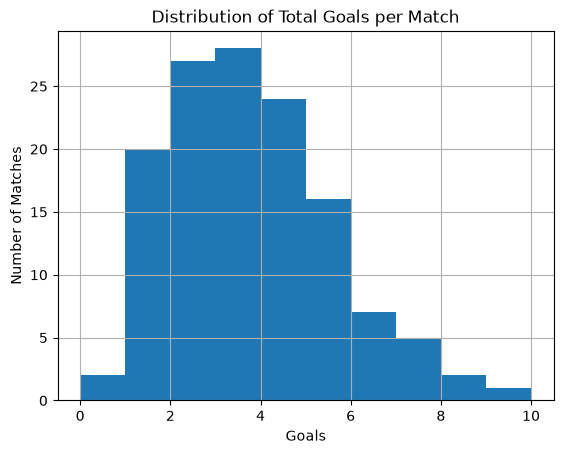

In [27]:
matches_fawsl["total_goals"].hist(bins=10)

plt.title("Distribution of Total Goals per Match")
plt.xlabel("Goals")
plt.ylabel("Number of Matches")
plt.show()

In [28]:
matches_fawsl.loc[
    0,
    [
        "match_id",
        "match_date",
        "home_team",
        "away_team",
        "home_score",
        "away_score",
        "stadium",
        "referee"
    ]
]

match_id                         3913082
match_date                    2023-11-05
home_team     Brighton & Hove Albion WFC
away_team            Manchester United W
home_score                             2
away_score                             2
stadium               Broadfield Stadium
referee                  Elizabeth Simms
Name: 0, dtype: object

In [29]:
first_match_id = matches_fawsl.iloc[0]["match_id"]

first_match_id

np.int64(3913082)

## Conclusion

The FA Women's Super League (2023/2024) dataset was selected as the primary data source for this project.

The dataset contains 132 matches and provides comprehensive match-level information. Based on this exploration, the next step is to collect detailed event-level data (passes, shots, duels, dribbles and other in-game actions), which will be used for player performance analysis and predictive modeling.